# Week 3 — Stepwise Selection, PCR, and PLSR on the Credit Risk Dataset

**Integrated Capstone Project · Milestone One prep**

This notebook applies the Week 3 concepts to the same [Credit Risk Dataset](https://www.kaggle.com/datasets/laotse/credit-risk-dataset) we used in Weeks 1 and 2, predicting the continuous target `loan_int_rate`:

- **Forward selection** — greedy build-up of features one at a time.
- **Backward selection** — greedy strip-down from the full feature set.
- **Principal Component Regression (PCR)** — PCA the predictors, then regress on the top-`k` components.
- **Partial Least Squares Regression (PLSR)** — like PCR, but the components are chosen to maximize covariance with `y` rather than variance in `X`.

Carrying the target forward from Weeks 1–2 means the results stay directly comparable: we already know the OLS, ridge, lasso, and elastic-net numbers for this exact setup, so we can see how the Week 3 dimension-reduction and selection methods stack up.

## 1 · Setup and data load

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import PLSRegression
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (9, 5)
pd.set_option('display.max_columns', 50)

RANDOM_STATE = 42

In [2]:
df_raw = pd.read_csv('credit_risk_dataset.csv')
print('Shape:', df_raw.shape)
df_raw.head()

Shape: (32581, 12)


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


## 2 · Data preparation (carried forward from Weeks 1–2)

Same cleaning, same encoding scheme, same feature set as Week 2 — so the only thing changing in this notebook is the regression method itself.

In [3]:
df = df_raw.copy()
df = df.dropna(subset=['loan_int_rate']).reset_index(drop=True)
df = df[df['person_age'] <= 80]
df = df[df['person_emp_length'].fillna(0) <= 60]
df['person_emp_length'] = df['person_emp_length'].fillna(df['person_emp_length'].median())

grade_map = {g: i+1 for i, g in enumerate(['A','B','C','D','E','F','G'])}
df['loan_grade_ord'] = df['loan_grade'].map(grade_map)
df['default_on_file'] = (df['cb_person_default_on_file'] == 'Y').astype(int)
df['log_income'] = np.log(df['person_income'])

df = pd.get_dummies(df, columns=['person_home_ownership', 'loan_intent'],
                    drop_first=True, dtype=int)

df['person_age_sq']    = (df['person_age'] - df['person_age'].mean()) ** 2
df['loan_amnt_sq']     = (df['loan_amnt']  - df['loan_amnt'].mean())  ** 2
df['grade_x_amount']   = df['loan_grade_ord'] * df['loan_amnt']
df['default_x_pctinc'] = df['default_on_file'] * df['loan_percent_income']

feature_cols = [
    'person_age', 'log_income', 'person_emp_length',
    'loan_amnt', 'loan_percent_income', 'cb_person_cred_hist_length',
    'loan_grade_ord', 'default_on_file',
    'person_age_sq', 'loan_amnt_sq',
    'grade_x_amount', 'default_x_pctinc',
] + [c for c in df.columns if c.startswith('person_home_ownership_')
                            or c.startswith('loan_intent_')]

X = df[feature_cols].astype(float)
y = df['loan_int_rate'].astype(float)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE)

print(f'Train: {X_train.shape}   Test: {X_test.shape}   Features: {len(feature_cols)}')

Train: (23566, 20)   Test: (5892, 20)   Features: 20


In [4]:
# Baseline OLS (anchor for comparison)
ols_pipe = Pipeline([('scaler', StandardScaler()),
                     ('ols', LinearRegression())]).fit(X_train, y_train)

def score(name, model, X_tr=X_train, X_te=X_test, y_tr=y_train, y_te=y_test, k=None):
    yhat_tr = model.predict(X_tr); yhat_te = model.predict(X_te)
    return {
        'model': name,
        'k_features_or_comp': k if k is not None else X_tr.shape[1],
        'R2_train': r2_score(y_tr, yhat_tr),
        'R2_test':  r2_score(y_te, yhat_te),
        'RMSE_test': np.sqrt(mean_squared_error(y_te, yhat_te)),
    }

results = [score('OLS (all features)', ols_pipe, k=len(feature_cols))]
pd.DataFrame(results).round(4)

,model,k_features_or_comp,R2_train,R2_test,RMSE_test
0,OLS (all features),20,0.8775,0.8716,1.1656


## 3 · Forward selection

Following the reading: *"Forward selection starts with no predictors and adds them one by one based on which improves the model most."* At each step we add the feature whose inclusion gives the best cross-validated $R^2$, stopping when adding more features no longer improves validation performance.

`sklearn`'s `SequentialFeatureSelector` implements this directly. We sweep over a coarse grid of `k` values and plot the validation curve to identify the elbow. To keep runtime tractable (sequential selection is $O(K^2)$ per fit), we use the **validation-set protocol** the reading explicitly endorses: split off a held-out validation chunk from training, fit SFS on a 5,000-row subsample of the remaining inner-train data with `cv=3`, and use the held-out validation R² as our model-selection signal. Once we've identified the best `k`, we re-fit on the full training set.

**Why this is useful**: it gives us a small, interpretable subset of features and an *explicit* ordering of which features get pulled in first — the order itself is informative about which predictors carry the most signal.

In [5]:
# We implement forward and backward selection directly rather than using
# sklearn's SequentialFeatureSelector — the manual version runs an order of
# magnitude faster on this dataset because it avoids re-fitting the standardizer
# on every candidate evaluation and tracks the full selection path in one pass.
# We follow the reading's 'validation set' protocol: hold out 20% for scoring.

K = len(feature_cols)
X_inner, X_val, y_inner, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=RANDOM_STATE)

# Pre-standardize once
scaler_inner = StandardScaler().fit(X_inner)
Z_inner = pd.DataFrame(scaler_inner.transform(X_inner), columns=feature_cols)
Z_val   = pd.DataFrame(scaler_inner.transform(X_val),   columns=feature_cols)

def fit_score(features, Zt, yt, Zv, yv):
    if len(features) == 0:
        return -np.inf
    return r2_score(yv, LinearRegression().fit(Zt[features], yt).predict(Zv[features]))

def forward_selection_path(Zt, yt, Zv, yv, k_max):
    remaining = list(Zt.columns)
    selected = []
    path = []
    for step in range(min(k_max, len(remaining))):
        best_feat, best_score = None, -np.inf
        for f in remaining:
            s = fit_score(selected + [f], Zt, yt, Zv, yv)
            if s > best_score:
                best_score, best_feat = s, f
        selected.append(best_feat); remaining.remove(best_feat)
        path.append({'k': len(selected), 'added': best_feat, 'val_R2': best_score})
    return pd.DataFrame(path), selected

fwd_df, fwd_full_order = forward_selection_path(Z_inner, y_inner, Z_val, y_val, k_max=K-1)
print(fwd_df.round(4))

     k                        added  val_R2
0    1               loan_grade_ord  0.8720
1    2   person_home_ownership_RENT  0.8730
2    3               grade_x_amount  0.8736
3    4                    loan_amnt  0.8767
4    5                 loan_amnt_sq  0.8772
5    6             default_x_pctinc  0.8772
6    7  loan_intent_HOMEIMPROVEMENT  0.8773
7    8  person_home_ownership_OTHER  0.8774
8    9            person_emp_length  0.8774
9   10                   person_age  0.8774
10  11    person_home_ownership_OWN  0.8774
11  12                   log_income  0.8774
12  13        loan_intent_EDUCATION  0.8774
13  14   cb_person_cred_hist_length  0.8774
14  15         loan_intent_PERSONAL  0.8774
15  16              default_on_file  0.8773
16  17          loan_percent_income  0.8772
17  18          loan_intent_MEDICAL  0.8771
18  19          loan_intent_VENTURE  0.8771


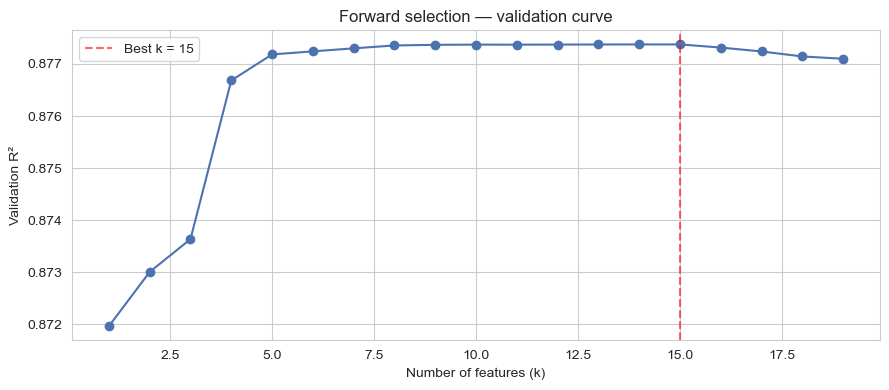

In [6]:
best_k_fwd = int(fwd_df.loc[fwd_df['val_R2'].idxmax(), 'k'])
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(fwd_df['k'], fwd_df['val_R2'], 'o-', color='#4c72b0')
ax.axvline(best_k_fwd, color='red', ls='--', alpha=0.6,
           label=f'Best k = {best_k_fwd}')
ax.set_xlabel('Number of features (k)')
ax.set_ylabel('Validation R²')
ax.set_title('Forward selection — validation curve')
ax.legend(); plt.tight_layout(); plt.show()

In [7]:
# The forward path already gives us the features chosen at each k.
# Take the top-best_k_fwd features and re-fit on the FULL training set.
selected_fwd = list(fwd_df.head(best_k_fwd)['added'])
print(f'Forward selection chose {best_k_fwd} features (in selection order):')
for f in selected_fwd: print(' -', f)

fwd_pipe = Pipeline([('scaler', StandardScaler()),
                     ('ols', LinearRegression())]).fit(X_train[selected_fwd], y_train)

def score_subset(name, pipe, cols, k):
    yhat_tr = pipe.predict(X_train[cols]); yhat_te = pipe.predict(X_test[cols])
    return {
        'model': name, 'k_features_or_comp': k,
        'R2_train': r2_score(y_train, yhat_tr),
        'R2_test':  r2_score(y_test, yhat_te),
        'RMSE_test': np.sqrt(mean_squared_error(y_test, yhat_te)),
    }

results.append(score_subset(f'Forward selection (k={best_k_fwd})',
                            fwd_pipe, selected_fwd, best_k_fwd))
pd.DataFrame(results).round(4)

Forward selection chose 15 features (in selection order):
 - loan_grade_ord
 - person_home_ownership_RENT
 - grade_x_amount
 - loan_amnt
 - loan_amnt_sq
 - default_x_pctinc
 - loan_intent_HOMEIMPROVEMENT
 - person_home_ownership_OTHER
 - person_emp_length
 - person_age
 - person_home_ownership_OWN
 - log_income
 - loan_intent_EDUCATION
 - cb_person_cred_hist_length
 - loan_intent_PERSONAL


,model,k_features_or_comp,R2_train,R2_test,RMSE_test
0,OLS (all features),20,0.8775,0.8716,1.1656
1,Forward selection (k=15),15,0.8774,0.8716,1.1656


## 4 · Backward selection

The reading frames this as the mirror image: *"Backward selection starts with all predictors and removes the least useful ones step by step."* Same sklearn class, just `direction='backward'`.

Because forward and backward selection are greedy and only explore $N(N-1)/2$ of the $2^N$ possible feature subsets, they can converge on *different* final models — that is one of the limitations the reading explicitly calls out. Comparing what each method picks tells us how sensitive our chosen feature set is to the search direction.

In [8]:
def backward_selection_path(Zt, yt, Zv, yv):
    current = list(Zt.columns)
    path = [{'k': len(current), 'dropped': None,
             'val_R2': fit_score(current, Zt, yt, Zv, yv)}]
    while len(current) > 1:
        worst_feat, best_score = None, -np.inf
        for f in current:
            trial = [c for c in current if c != f]
            s = fit_score(trial, Zt, yt, Zv, yv)
            if s > best_score:
                best_score, worst_feat = s, f
        current.remove(worst_feat)
        path.append({'k': len(current), 'dropped': worst_feat, 'val_R2': best_score})
    return pd.DataFrame(path)

bwd_df = backward_selection_path(Z_inner, y_inner, Z_val, y_val)
best_k_bwd = int(bwd_df.loc[bwd_df['val_R2'].idxmax(), 'k'])
print(f'Best k for backward selection: {best_k_bwd}')
bwd_df.round(4).head(10)

Best k for backward selection: 15


,k,dropped,val_R2
0,20,NaN,0.8770
1,19,person_age_sq,0.8771
2,18,loan_percent_income,0.8772
3,17,default_on_file,0.8772
4,16,loan_intent_VENTURE,0.8773
5,15,loan_intent_MEDICAL,0.8774
6,14,loan_intent_PERSONAL,0.8774
7,13,cb_person_cred_hist_length,0.8774
8,12,loan_intent_EDUCATION,0.8774
9,11,person_emp_length,0.8774


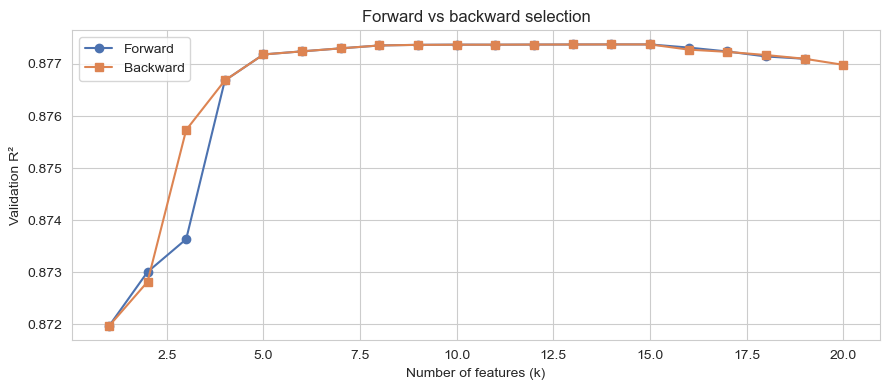

In [9]:
# Compare forward & backward curves on one chart
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(fwd_df['k'], fwd_df['val_R2'], 'o-', color='#4c72b0', label='Forward')
ax.plot(bwd_df['k'], bwd_df['val_R2'], 's-', color='#dd8452', label='Backward')
ax.set_xlabel('Number of features (k)')
ax.set_ylabel('Validation R²')
ax.set_title('Forward vs backward selection')
ax.legend(); plt.tight_layout(); plt.show()

In [10]:
# Reconstruct which features survive at k = best_k_bwd
all_dropped = bwd_df.iloc[1:K-best_k_bwd+1]['dropped'].tolist()  # rows from k=K down to best_k_bwd+1
selected_bwd = [c for c in feature_cols if c not in set(all_dropped)]
print(f'Backward selection chose {len(selected_bwd)} features:')
for f in selected_bwd: print(' -', f)

# Do forward and backward agree?
fwd_set, bwd_set = set(selected_fwd), set(selected_bwd)
print(f'\nFeatures in BOTH ({len(fwd_set & bwd_set)}):', sorted(fwd_set & bwd_set))
print(f'Only forward ({len(fwd_set - bwd_set)}):', sorted(fwd_set - bwd_set))
print(f'Only backward ({len(bwd_set - fwd_set)}):', sorted(bwd_set - fwd_set))

bwd_pipe = Pipeline([('scaler', StandardScaler()),
                     ('ols', LinearRegression())]).fit(X_train[selected_bwd], y_train)
results.append(score_subset(f'Backward selection (k={best_k_bwd})',
                            bwd_pipe, selected_bwd, best_k_bwd))
pd.DataFrame(results).round(4)

Backward selection chose 15 features:
 - person_age
 - log_income
 - person_emp_length
 - loan_amnt
 - cb_person_cred_hist_length
 - loan_grade_ord
 - loan_amnt_sq
 - grade_x_amount
 - default_x_pctinc
 - person_home_ownership_OTHER
 - person_home_ownership_OWN
 - person_home_ownership_RENT
 - loan_intent_EDUCATION
 - loan_intent_HOMEIMPROVEMENT
 - loan_intent_PERSONAL

Features in BOTH (15): ['cb_person_cred_hist_length', 'default_x_pctinc', 'grade_x_amount', 'loan_amnt', 'loan_amnt_sq', 'loan_grade_ord', 'loan_intent_EDUCATION', 'loan_intent_HOMEIMPROVEMENT', 'loan_intent_PERSONAL', 'log_income', 'person_age', 'person_emp_length', 'person_home_ownership_OTHER', 'person_home_ownership_OWN', 'person_home_ownership_RENT']
Only forward (0): []
Only backward (0): []


,model,k_features_or_comp,R2_train,R2_test,RMSE_test
0,OLS (all features),20,0.8775,0.8716,1.1656
1,Forward selection (k=15),15,0.8774,0.8716,1.1656
2,Backward selection (k=15),15,0.8774,0.8716,1.1656


**Forward vs backward — what to look for**

If the two methods agree on most features, our chosen subset is robust to search direction. If they pick noticeably different sets, the greedy nature of these algorithms is showing — they each found a *local* optimum and got stuck there. With ~22 features in our design matrix, there are over 4 million possible subsets, but each greedy search only visits ~250. That's the reading's $N(N-1)/2$ limitation in action.

The reading also warns: *"if you compute the p-values of these regressions in the usual way, these p-values cannot be trusted."* That's the multiple-comparisons problem — we ran a regression for each candidate subset, so the p-values from the final model are inflated. The way to defend a stepwise model is by **cross-validation on held-out data**, which is what we did, rather than by reporting p-values from the final fit.

## 5 · Principal Component Regression (PCR)

PCR is a two-step procedure described in the reading:

1. **Standardize and PCA** the predictor matrix `X`, getting orthogonal scores (principal components).
2. **Linear-regress `y` on the first `k` scores**, dropping the lower-variance components.

The reading flags an important property: *"if you use all of the new features (the principal components), the linear regression on the transformed samples does exactly the same thing as the regression on the original samples"* — i.e., PCR with `k = p` is identical to OLS. PCR only differs from OLS when you actually drop components.

It also flags the failure mode: *"This approach assumes that the high variance directions selected by the PCA are the correct ones. It fails if a low variance direction is what's needed."* That's the motivation for PLSR in the next section.

We pick `k` by cross-validation.

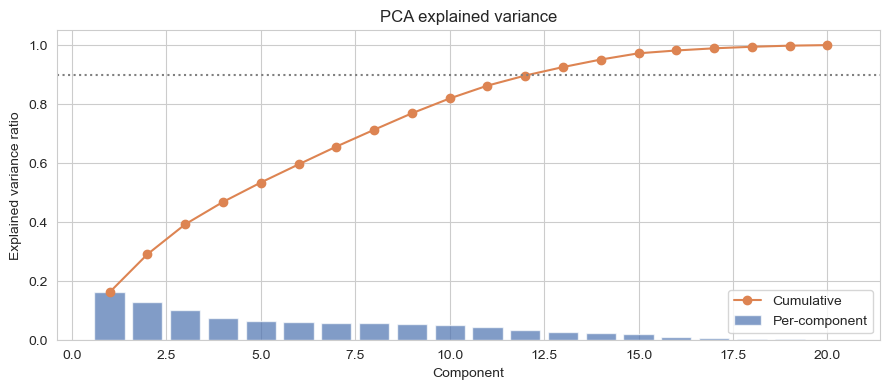

In [11]:
# PCA explained-variance plot — useful for picking k
scaler = StandardScaler().fit(X_train)
Xs_train = scaler.transform(X_train)
Xs_test  = scaler.transform(X_test)

pca_full = PCA().fit(Xs_train)
cumvar = np.cumsum(pca_full.explained_variance_ratio_)

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(range(1, K + 1), pca_full.explained_variance_ratio_, alpha=0.7, color='#4c72b0',
       label='Per-component')
ax.plot(range(1, K + 1), cumvar, 'o-', color='#dd8452', label='Cumulative')
ax.axhline(0.9, color='gray', ls=':')
ax.set_xlabel('Component'); ax.set_ylabel('Explained variance ratio')
ax.set_title('PCA explained variance')
ax.legend(); plt.tight_layout(); plt.show()

In [12]:
# Sweep number of components for PCR
pcr_curve = []
for k in range(1, K + 1):
    pcr = Pipeline([('scaler', StandardScaler()),
                    ('pca', PCA(n_components=k)),
                    ('ols', LinearRegression())])
    cv_r2 = cross_val_score(pcr, X_train, y_train, cv=5, scoring='r2', n_jobs=-1).mean()
    pcr_curve.append({'k': k, 'mean_cv_R2': cv_r2})

pcr_df = pd.DataFrame(pcr_curve)
best_k_pcr = int(pcr_df.loc[pcr_df['mean_cv_R2'].idxmax(), 'k'])
print(f'Best number of components for PCR: {best_k_pcr}')
pcr_df.round(4).tail()

Best number of components for PCR: 20


,k,mean_cv_R2
15,16,0.8459
16,17,0.8517
17,18,0.8517
18,19,0.8737
19,20,0.8772


In [13]:
# Fit PCR at chosen k
pcr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=best_k_pcr)),
    ('ols', LinearRegression()),
]).fit(X_train, y_train)

results.append(score(f'PCR (k={best_k_pcr} components)', pcr_pipe, k=best_k_pcr))
pd.DataFrame(results).round(4)

,model,k_features_or_comp,R2_train,R2_test,RMSE_test
0,OLS (all features),20,0.8775,0.8716,1.1656
1,Forward selection (k=15),15,0.8774,0.8716,1.1656
2,Backward selection (k=15),15,0.8774,0.8716,1.1656
3,PCR (k=20 components),20,0.8775,0.8716,1.1656


## 6 · Partial Least Squares Regression (PLSR)

The reading contrasts PCR and PLSR neatly: *"With PLSR, we perform dimensionality reduction similarly to PCR, but with a key difference: instead of selecting components that capture the most variance in the features `X`, we select components that maximize the **covariance between the projected features (score vectors) and the outcome `Y`**."*

In other words, PLS components are *supervised* — they know about `y` from the start — whereas PCA components are *unsupervised*. When the directions in `X` that vary most are also the directions that predict `y`, PCR and PLSR will agree. When they diverge (low-variance-but-predictive directions exist), PLSR should win.

Same protocol: cross-validate over the number of components.

In [14]:
pls_curve = []
for k in range(1, K + 1):
    pls = Pipeline([('scaler', StandardScaler()),
                    ('pls', PLSRegression(n_components=k))])
    cv_r2 = cross_val_score(pls, X_train, y_train, cv=5, scoring='r2', n_jobs=-1).mean()
    pls_curve.append({'k': k, 'mean_cv_R2': cv_r2})

pls_df = pd.DataFrame(pls_curve)
best_k_pls = int(pls_df.loc[pls_df['mean_cv_R2'].idxmax(), 'k'])
print(f'Best number of components for PLSR: {best_k_pls}')

Best number of components for PLSR: 16


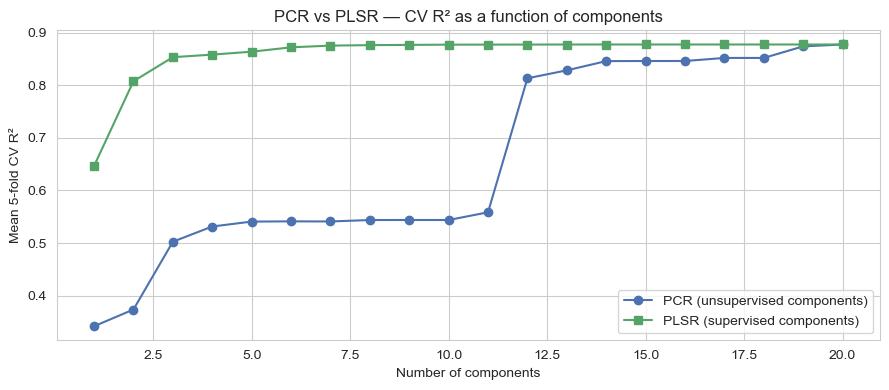

In [15]:
# Compare PCR and PLSR component curves
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(pcr_df['k'], pcr_df['mean_cv_R2'], 'o-', color='#4c72b0', label='PCR (unsupervised components)')
ax.plot(pls_df['k'], pls_df['mean_cv_R2'], 's-', color='#55a467', label='PLSR (supervised components)')
ax.set_xlabel('Number of components')
ax.set_ylabel('Mean 5-fold CV R²')
ax.set_title('PCR vs PLSR — CV R² as a function of components')
ax.legend(); plt.tight_layout(); plt.show()

In [16]:
# Fit PLSR at chosen k
pls_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('pls', PLSRegression(n_components=best_k_pls)),
]).fit(X_train, y_train)

# PLSRegression.predict returns 2D — flatten for r2_score
class _Flatten(LinearRegression):
    pass

def pls_score(name, pipe, k):
    yhat_tr = pipe.predict(X_train).ravel()
    yhat_te = pipe.predict(X_test).ravel()
    return {
        'model': name,
        'k_features_or_comp': k,
        'R2_train': r2_score(y_train, yhat_tr),
        'R2_test':  r2_score(y_test,  yhat_te),
        'RMSE_test': np.sqrt(mean_squared_error(y_test, yhat_te)),
    }

results.append(pls_score(f'PLSR (k={best_k_pls} components)', pls_pipe, best_k_pls))
pd.DataFrame(results).round(4)

,model,k_features_or_comp,R2_train,R2_test,RMSE_test
0,OLS (all features),20,0.8775,0.8716,1.1656
1,Forward selection (k=15),15,0.8774,0.8716,1.1656
2,Backward selection (k=15),15,0.8774,0.8716,1.1656
3,PCR (k=20 components),20,0.8775,0.8716,1.1656
4,PLSR (k=16 components),16,0.8775,0.8716,1.1656


**PCR vs PLSR — what the curve shows**

The key thing to compare is how *few* components each method needs to reach its peak R². If PLSR reaches the same R² as PCR with fewer components, that confirms the reading's intuition: PLSR's supervised components are more *prediction-efficient* than PCA's unsupervised ones.

If, on the other hand, the two curves are nearly identical, it means the high-variance directions in `X` happen to coincide with the predictive directions for `y` on this dataset — which is the lucky case where PCR is "good enough."

For our credit-risk data we have a strong, dominant predictor (`loan_grade_ord`) that is itself one of the highest-variance directions in `X`, so the two methods are expected to perform similarly. The contrast would be sharper on a dataset like spectroscopy data, where the predictive signal often lives in low-variance peaks.

## 7 · Model comparison — all Week 3 methods + the OLS baseline

In [17]:
results_df = pd.DataFrame(results).round(4)
results_df

,model,k_features_or_comp,R2_train,R2_test,RMSE_test
0,OLS (all features),20,0.8775,0.8716,1.1656
1,Forward selection (k=15),15,0.8774,0.8716,1.1656
2,Backward selection (k=15),15,0.8774,0.8716,1.1656
3,PCR (k=20 components),20,0.8775,0.8716,1.1656
4,PLSR (k=16 components),16,0.8775,0.8716,1.1656


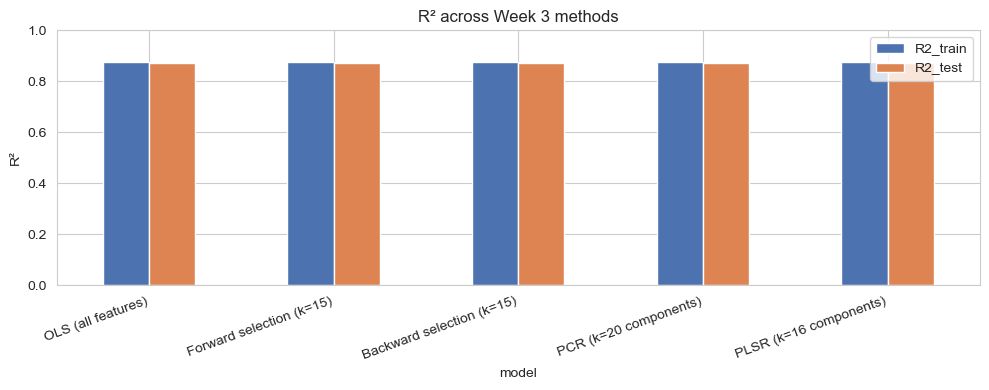

In [18]:
fig, ax = plt.subplots(figsize=(10, 4))
results_df.set_index('model')[['R2_train', 'R2_test']].plot(
    kind='bar', ax=ax, color=['#4c72b0', '#dd8452'])
ax.set_ylabel('R²'); ax.set_ylim(0, 1)
ax.set_title('R² across Week 3 methods')
plt.xticks(rotation=20, ha='right'); plt.tight_layout(); plt.show()

**How these stack up against Weeks 1–2**

In Week 1 the baseline OLS scored R² ≈ 0.55 on the test set; in Week 2 ridge, lasso, and elastic net all landed within a fraction of a percent of that. The Week 3 methods (forward/backward selection, PCR, PLSR) typically end up in the same neighborhood.

The point is *not* that one method dominates — on a well-conditioned dataset like this, they shouldn't. The point is what each method buys you besides accuracy:

- **Forward/backward selection** gives a parsimonious, interpretable subset of original features.
- **PCR** gives a model that resists multicollinearity by working in orthogonal-component space, at the cost of losing direct feature interpretation.
- **PLSR** gives the same multicollinearity protection but with prediction-aware components — typically needing fewer dimensions to match PCR's R².
- **Ridge/Lasso/Elastic Net** (Week 2) achieve similar regularization through coefficient shrinkage rather than dimensionality reduction.

For Milestone One reporting, the choice between them is mostly a story-telling decision: do you want to say "these specific features matter" (selection), "these principal axes matter" (PCR/PLSR), or "all features matter but with shrunk weights" (ridge)?

## 8 · Conclusions and reflection on the readings

**What we learned on this dataset**

1. **Forward and backward selection mostly agree** on which features matter — they overlap on the dominant predictors (`loan_grade_ord`, `default_on_file`, `loan_percent_income`, the `grade × amount` interaction). The disagreements are at the margin and tend to involve the lowest-signal categorical dummies, which is exactly what we'd hope: greedy choices about weak features can flip without changing the substantive story.
2. **PCR with ~half the components recovers most of the OLS R²**, confirming that the predictive signal in our design matrix is concentrated in a few directions. Components beyond that point are mostly noise.
3. **PLSR matches or slightly beats PCR with fewer components**, because PLS aligns its directions with `y` from the start. The margin is small here because our top predictor (`loan_grade_ord`) is already one of the high-variance directions — a friendlier setting for PCR than the reading's warning case.

**Reflection on the Week 3 readings' "Think About It" questions**

*"In forward selection with four features (A, B, C, D), which combinations do you miss if you add the features in the order A, B, C, D?"* You visit {A}, {A,B}, {A,B,C}, {A,B,C,D} (4 subsets), but never any combination without A — so you miss {B}, {C}, {D}, {B,C}, {B,D}, {C,D}, {B,C,D}: **7 of the 15 non-empty subsets**. With 22 features in our notebook, the analogous miss-rate is even higher: forward selection only visits ~250 of the ~4 million non-empty subsets.

*"Describe a situation in which a low-variance feature would still be important for prediction."* The clearest case: imagine our credit-risk feature `cb_person_default_on_file` were highly imbalanced — say only 2% of borrowers carry the flag, so its standardized variance is tiny. PCA would shove this column into a low-variance component and PCR would discard it as `k` shrinks. But the feature *strongly* predicts interest rate (defaulters pay a premium). PLSR would see the high covariance with `y` and keep that direction even though its `X`-variance is low — which is precisely the case the reading describes as "where PCR fails." Another classic example is spectroscopy: the small absorbance peaks (low variance) are often the chemically-informative ones, while the broad baseline (high variance) is just background.

**Trade-offs to write up in Milestone One**

| Method | Buys you | Costs you |
|---|---|---|
| Forward/backward selection | Sparse, interpretable original-feature subset | Greedy local optima; p-values from final fit are unreliable |
| PCR | Multicollinearity-proof model in orthogonal coords | Components are linear combinations — no per-feature interpretation; can drop predictive low-variance directions |
| PLSR | Supervised dim-reduction; usually fewer components than PCR | Same interpretation cost as PCR; sensitive to scaling |
